<a href="https://colab.research.google.com/github/jayanth-talasri/Solar-irradiance-forecasting-using-deep-Learning-model-LSTM-/blob/main/solar_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
summer = pd.read_csv("/content/Summer_2004-2006.csv")
rainy = pd.read_csv("/content/Raini_2004-2006.csv")
winter = pd.read_csv("/content/Winter_2004-2006.csv")

print("Summer Shape:", summer.shape)
print("Rainy Shape:", rainy.shape)
print("Winter Shape:", winter.shape)

Summer Shape: (52416, 11)
Rainy Shape: (53136, 11)
Winter Shape: (51983, 11)


In [18]:
summer.columns = summer.columns.str.strip()

print(summer.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [ ]:
print(summer.columns)
print(rainy.columns)
print(winter.columns)

# **Summer Season Forecasting**

In [19]:
summer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date Time               52416 non-null  object 
 1   Time                    52416 non-null  object 
 2   Temperature             52416 non-null  float64
 3   Relative Humidity       52416 non-null  float64
 4   Pressure                52416 non-null  float64
 5   Wind speed              52416 non-null  float64
 6   Wind direction          52416 non-null  float64
 7   Rainfall                52416 non-null  float64
 8   Snowfall                52416 non-null  int64  
 9   Snow depth              52416 non-null  int64  
 10  Short-wave irradiation  52416 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.4+ MB


In [21]:
summer.isnull().sum()

,0
Date Time,0
Time,0
Temperature,0
Relative Humidity,0
Pressure,0
Wind speed,0
Wind direction,0
Rainfall,0
Snowfall,0
Snow depth,0


In [22]:
summer["Datetime"] = pd.to_datetime(
    summer["Date Time"].astype(str) + " " + summer["Time"].astype(str)
)

print(summer[["Date Time", "Time", "Datetime"]].head())

  Date Time  Time            Datetime
0  3/1/2004  0:00 2004-03-01 00:00:00
1  3/1/2004  0:10 2004-03-01 00:10:00
2  3/1/2004  0:20 2004-03-01 00:20:00
3  3/1/2004  0:30 2004-03-01 00:30:00
4  3/1/2004  0:40 2004-03-01 00:40:00


In [23]:
summer = summer.sort_values("Datetime")

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Datetime
0,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0,2004-03-01 00:00:00
1,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0,2004-03-01 00:10:00
2,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0,2004-03-01 00:20:00
3,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0,2004-03-01 00:30:00
4,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0,2004-03-01 00:40:00


In [24]:
summer.set_index("Datetime", inplace=True)

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation
Datetime,,,,,,,,,,,
2004-03-01 00:00:00,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0
2004-03-01 00:10:00,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0
2004-03-01 00:20:00,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0
2004-03-01 00:30:00,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0
2004-03-01 00:40:00,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0


In [25]:
summer["Hour"] = summer.index.hour
summer["Day"] = summer.index.day
summer["Month"] = summer.index.month

summer.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Hour,Day,Month
Datetime,,,,,,,,,,,,,,
2004-03-01 00:00:00,3/1/2004,0:00,293.41,80.33,1005.01,2.74,300.73,0.0,0,0,0.0,0,1,3
2004-03-01 00:10:00,3/1/2004,0:10,293.37,79.86,1005.16,2.76,302.82,0.0,0,0,0.0,0,1,3
2004-03-01 00:20:00,3/1/2004,0:20,293.32,79.39,1005.31,2.77,304.89,0.0,0,0,0.0,0,1,3
2004-03-01 00:30:00,3/1/2004,0:30,293.27,78.92,1005.47,2.80,306.92,0.0,0,0,0.0,0,1,3
2004-03-01 00:40:00,3/1/2004,0:40,293.44,77.53,1005.62,2.86,308.77,0.0,0,0,0.0,0,1,3


In [26]:
features = [
    "Temperature",
    "Relative Humidity",
    "Pressure",
    "Wind speed",
    "Wind direction",
    "Rainfall",
    "Snowfall",
    "Snow depth",
    "Hour",
    "Day",
    "Month"
]

In [27]:
target = "Short-wave irradiation"

In [28]:
X = summer[features]
y = summer[target]

print(X.head())
print(y.head())

                     Temperature  Relative Humidity  Pressure  Wind speed  \
Datetime                                                                    
2004-03-01 00:00:00       293.41              80.33   1005.01        2.74   
2004-03-01 00:10:00       293.37              79.86   1005.16        2.76   
2004-03-01 00:20:00       293.32              79.39   1005.31        2.77   
2004-03-01 00:30:00       293.27              78.92   1005.47        2.80   
2004-03-01 00:40:00       293.44              77.53   1005.62        2.86   

                     Wind direction  Rainfall  Snowfall  Snow depth  Hour  \
Datetime                                                                    
2004-03-01 00:00:00          300.73       0.0         0           0     0   
2004-03-01 00:10:00          302.82       0.0         0           0     0   
2004-03-01 00:20:00          304.89       0.0         0           0     0   
2004-03-01 00:30:00          306.92       0.0         0           0     0  

In [30]:
from sklearn.preprocessing import MinMaxScaler

In [31]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1))

In [32]:
print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (52416, 11)
y_scaled shape: (52416, 1)


In [33]:
X_scaled = pd.DataFrame(X_scaled, columns=features, index=summer.index)

y_scaled = pd.DataFrame(y_scaled, columns=[target], index=summer.index)

X_scaled.head()

,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Hour,Day,Month
Datetime,,,,,,,,,,,
2004-03-01 00:00:00,0.088855,0.802614,0.659333,0.181757,0.835845,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:10:00,0.087323,0.797029,0.664656,0.183099,0.841655,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:20:00,0.085408,0.791444,0.669979,0.183769,0.847409,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:30:00,0.083493,0.785859,0.675656,0.185781,0.853052,0.0,0.0,0.0,0.0,0.0,0.0
2004-03-01 00:40:00,0.090004,0.769340,0.680979,0.189805,0.858195,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
sequence_length = 24

In [34]:
def create_sequences(X, y, sequence_length):

    X_sequences = []
    y_sequences = []

    for i in range(sequence_length, len(X)):

        X_sequences.append(
            X.iloc[i-sequence_length:i].values
        )

        y_sequences.append(
            y.iloc[i].values
        )

    return np.array(X_sequences), np.array(y_sequences)

In [36]:
X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    sequence_length
)

In [37]:
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (52392, 24, 11)
y_seq shape: (52392, 1)


In [38]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test = y_seq[train_size:]

In [39]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (41913, 24, 11)
X_test shape: (10479, 24, 11)
y_train shape: (41913, 1)
y_test shape: (10479, 1)


Completed LSTM sequence generation

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [41]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

# Second LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))

# Dense Layers
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - loss: 0.0083 - mae: 0.0538 - val_loss: 0.0031 - val_mae: 0.0317
Epoch 2/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 0.0042 - mae: 0.0388 - val_loss: 0.0028 - val_mae: 0.0297
Epoch 3/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - loss: 0.0035 - mae: 0.0344 - val_loss: 0.0026 - val_mae: 0.0293
Epoch 4/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - loss: 0.0031 - mae: 0.0324 - val_loss: 0.0023 - val_mae: 0.0280
Epoch 5/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - loss: 0.0028 - mae: 0.0299 - val_loss: 0.0022 - val_mae: 0.0269
Epoch 6/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - loss: 0.0025 - mae: 0.0285 - val_loss: 0.0017 - val_mae: 0.0220
Epoch 7/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 0.0023 - mae: 0.0275 - val_loss: 0.0020 - val_mae: 0.0254
Epoch 8/20
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - loss: 0.0020 - mae: 0.0254 - val_loss: 0.0018 - val_mae: 0.0238
Epoch 9/20
1179/1179 ━━━

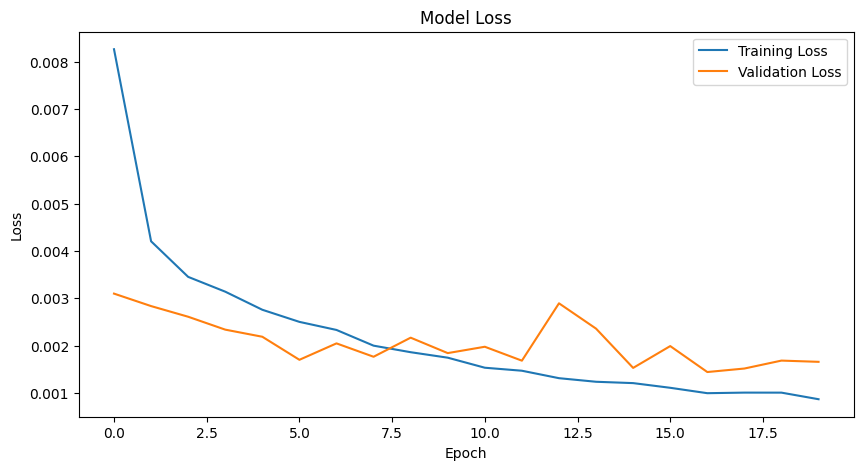

In [47]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [48]:
model.save("summer_lstm_model.h5")

Built and trained summer LSTM model

In [49]:
model.save("summer_lstm_model.keras")

In [50]:
y_pred = model.predict(X_test)

328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


In [51]:
y_pred_actual = target_scaler.inverse_transform(y_pred)

y_test_actual = target_scaler.inverse_transform(y_test)

In [52]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [53]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)

mse = mean_squared_error(y_test_actual, y_pred_actual)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 5.399615694987833
RMSE: 10.08782706002306
R² Score: 0.9463599826922829


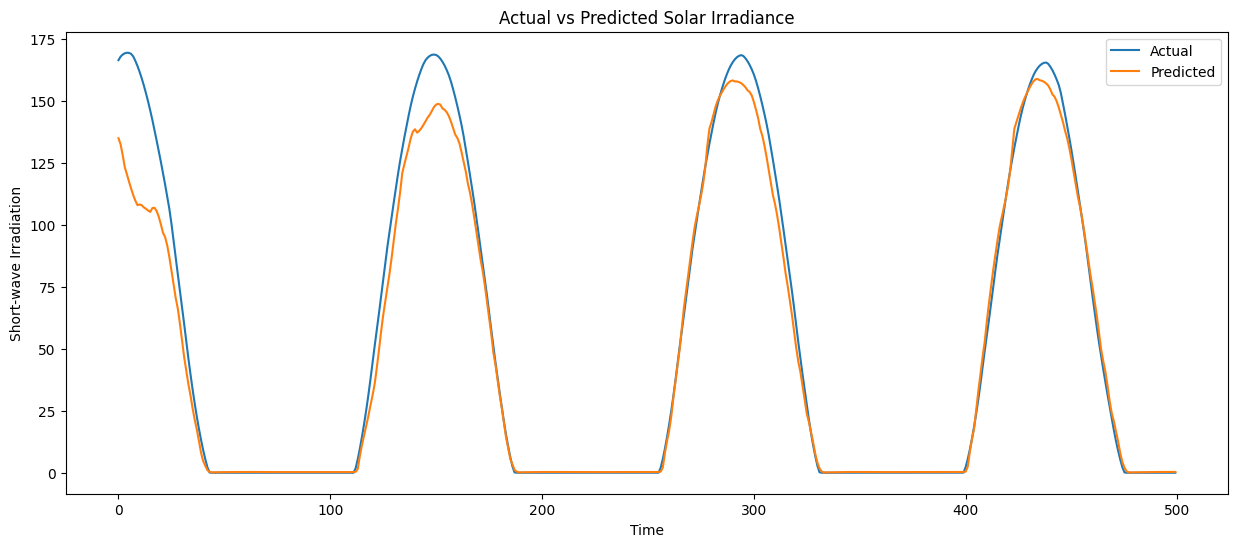

In [54]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test_actual[:500],
    label="Actual"
)

plt.plot(
    y_pred_actual[:500],
    label="Predicted"
)

plt.title("Actual vs Predicted Solar Irradiance")

plt.xlabel("Time")

plt.ylabel("Short-wave Irradiation")

plt.legend()

plt.show()

In [55]:
plt.savefig("summer_prediction_plot.png")

<Figure size 640x480 with 0 Axes>

Completed summer model evaluation

In [56]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_summer_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [59]:
improved_model = Sequential()

# First LSTM Layer
improved_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

improved_model.add(Dropout(0.3))

# Second LSTM Layer
improved_model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

improved_model.add(Dropout(0.3))

# Dense Layers
improved_model.add(Dense(32, activation='relu'))

improved_model.add(Dense(16, activation='relu'))

# Output Layer
improved_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [60]:
improved_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [61]:
history_improved = improved_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 65s 51ms/step - loss: 0.0083 - mae: 0.0537 - val_loss: 0.0037 - val_mae: 0.0360 - learning_rate: 0.0010
Epoch 2/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0042 - mae: 0.0382 - val_loss: 0.0033 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 3/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 62s 52ms/step - loss: 0.0035 - mae: 0.0346 - val_loss: 0.0035 - val_mae: 0.0348 - learning_rate: 0.0010
Epoch 4/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - loss: 0.0031 - mae: 0.0322 - val_loss: 0.0032 - val_mae: 0.0329 - learning_rate: 0.0010
Epoch 5/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 60s 51ms/step - loss: 0.0028 - mae: 0.0304 - val_loss: 0.0029 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 6/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - loss: 0.0026 - mae: 0.0291 - val_loss: 0.0022 - val_mae: 0.0274 - learning_rate: 0.0010
Epoch 7/50
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - loss: 0.0025 - mae: 0.0281 - val_loss: 0.0021 - val_mae: 0.0264 - 

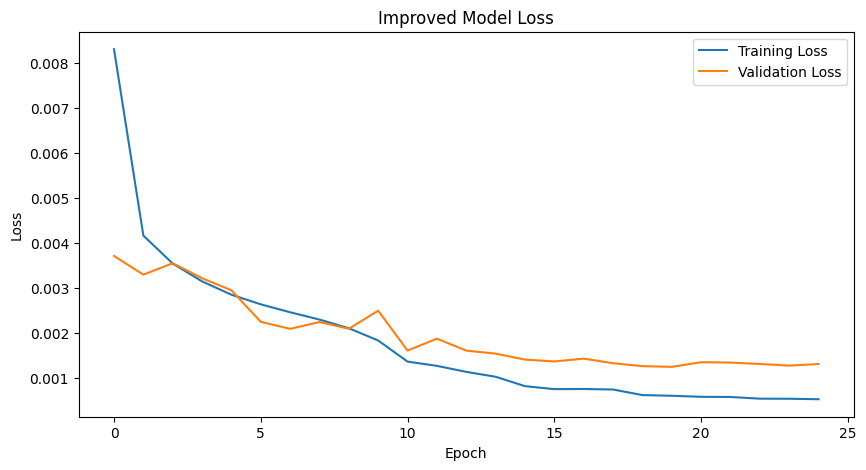

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

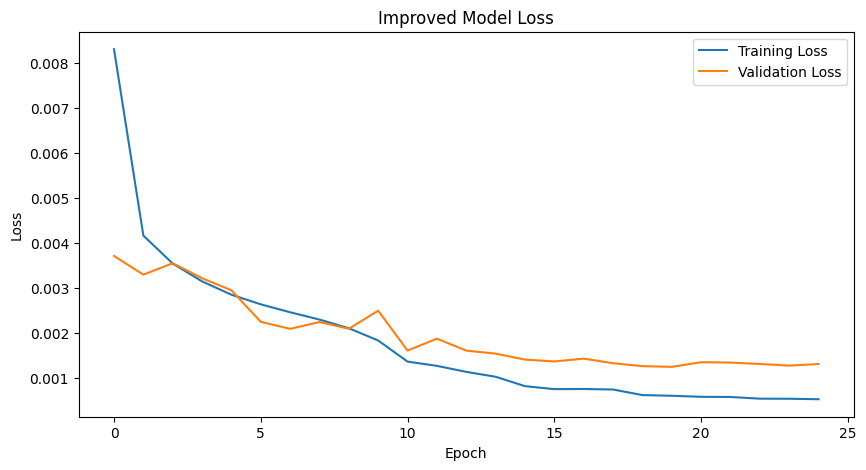

In [63]:
plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [64]:
import matplotlib.pyplot as plt

In [65]:
predictions = improved_model.predict(X_test)

print(predictions[:5])

328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
[[0.8656361 ]
 [0.84455013]
 [0.81910336]
 [0.78836095]
 [0.7607186 ]]


In [66]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 0.029776586928098626
RMSE: 0.05727888707727885
R2 Score: 0.9488593841678711


In [67]:
with open("metrics.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2 Score: {r2}\n")

In [68]:
improved_model.save("improved_lstm_model.keras")

In [69]:
import os
os.makedirs("results/graphs", exist_ok=True)

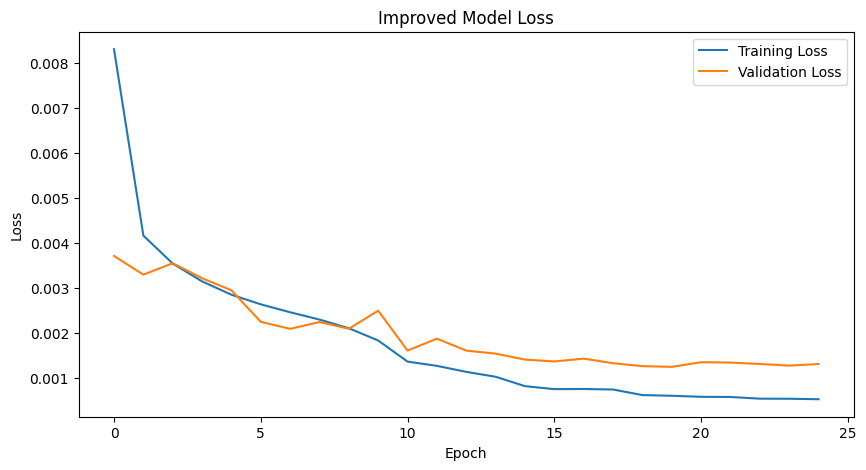

In [70]:
plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.savefig("results/graphs/Summer_loss_curve.png")

plt.show()

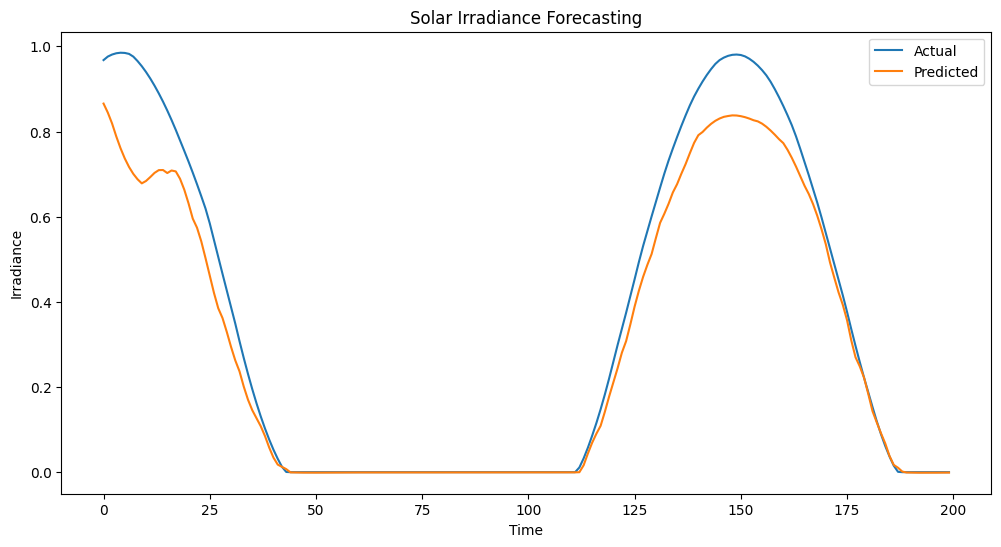

In [71]:
plt.figure(figsize=(12,6))

plt.plot(y_test[:200], label='Actual')

plt.plot(predictions[:200], label='Predicted')

plt.title("Solar Irradiance Forecasting")

plt.xlabel("Time")

plt.ylabel("Irradiance")

plt.legend()

plt.savefig("results/graphs/Summer_Prediction.png")

plt.show()

In [84]:
with open("results/summer-metrics.txt", "w") as f:

    f.write(f"MAE: {mae}\n")

    f.write(f"RMSE: {rmse}\n")

    f.write(f"R2 Score: {r2}\n")

# **Rainy Season Forecasting**

In [73]:
rainy.columns = rainy.columns.str.strip()

print(rainy.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [74]:
rainy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53136 entries, 0 to 53135
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date Time               53136 non-null  object 
 1   Time                    53136 non-null  object 
 2   Temperature             53136 non-null  float64
 3   Relative Humidity       53136 non-null  float64
 4   Pressure                53136 non-null  float64
 5   Wind speed              53136 non-null  float64
 6   Wind direction          53136 non-null  float64
 7   Rainfall                53136 non-null  float64
 8   Snowfall                53136 non-null  int64  
 9   Snow depth              53136 non-null  int64  
 10  Short-wave irradiation  53136 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.5+ MB


In [75]:
rainy.isnull().sum()

,0
Date Time,0
Time,0
Temperature,0
Relative Humidity,0
Pressure,0
Wind speed,0
Wind direction,0
Rainfall,0
Snowfall,0
Snow depth,0


In [80]:
rainy["Datetime"] = pd.to_datetime(

    rainy["Date Time"].astype(str)
    + " "
    + rainy["Time"].astype(str),

    format='mixed'
)

print(
    rainy[["Date Time", "Time", "Datetime"]].head()
)

    Date Time   Time            Datetime
0  07-01-2004  00:00 2004-07-01 00:00:00
1  07-01-2004  00:10 2004-07-01 00:10:00
2  07-01-2004  00:20 2004-07-01 00:20:00
3  07-01-2004  00:30 2004-07-01 00:30:00
4  07-01-2004  00:40 2004-07-01 00:40:00


In [82]:
rainy = rainy.sort_values("Datetime")

rainy.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Datetime
0,07-01-2004,00:00,300.53,88.45,995.13,2.59,258.19,0.054736,0,0,2.2794,2004-07-01 00:00:00
1,07-01-2004,00:10,300.65,87.88,995.23,2.84,258.35,0.055337,0,0,4.4490,2004-07-01 00:10:00
2,07-01-2004,00:20,300.77,87.31,995.33,3.08,258.49,0.055937,0,0,6.7664,2004-07-01 00:20:00
3,07-01-2004,00:30,300.90,86.75,995.42,3.33,258.60,0.056538,0,0,9.2049,2004-07-01 00:30:00
4,07-01-2004,00:40,301.05,85.89,995.52,3.53,260.22,0.056450,0,0,11.9117,2004-07-01 00:40:00


In [85]:
rainy.set_index("Datetime", inplace=True)
rainy.head()


,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation
Datetime,,,,,,,,,,,
2004-07-01 00:00:00,07-01-2004,00:00,300.53,88.45,995.13,2.59,258.19,0.054736,0,0,2.2794
2004-07-01 00:10:00,07-01-2004,00:10,300.65,87.88,995.23,2.84,258.35,0.055337,0,0,4.4490
2004-07-01 00:20:00,07-01-2004,00:20,300.77,87.31,995.33,3.08,258.49,0.055937,0,0,6.7664
2004-07-01 00:30:00,07-01-2004,00:30,300.90,86.75,995.42,3.33,258.60,0.056538,0,0,9.2049
2004-07-01 00:40:00,07-01-2004,00:40,301.05,85.89,995.52,3.53,260.22,0.056450,0,0,11.9117


In [86]:
rainy["Hour"] = rainy.index.hour
rainy["Day"] = rainy.index.day
rainy["Month"] = rainy.index.month
rainy.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Hour,Day,Month
Datetime,,,,,,,,,,,,,,
2004-07-01 00:00:00,07-01-2004,00:00,300.53,88.45,995.13,2.59,258.19,0.054736,0,0,2.2794,0,1,7
2004-07-01 00:10:00,07-01-2004,00:10,300.65,87.88,995.23,2.84,258.35,0.055337,0,0,4.4490,0,1,7
2004-07-01 00:20:00,07-01-2004,00:20,300.77,87.31,995.33,3.08,258.49,0.055937,0,0,6.7664,0,1,7
2004-07-01 00:30:00,07-01-2004,00:30,300.90,86.75,995.42,3.33,258.60,0.056538,0,0,9.2049,0,1,7
2004-07-01 00:40:00,07-01-2004,00:40,301.05,85.89,995.52,3.53,260.22,0.056450,0,0,11.9117,0,1,7


In [88]:
features = [
    "Temperature",
    "Relative Humidity",
    "Pressure",
    "Wind speed",
    "Wind direction",
    "Rainfall",
    "Snowfall",
    "Snow depth",
    "Hour",
    "Day",
    "Month"
]
target = "Short-wave irradiation"

In [90]:
X = rainy[features]
y = rainy[target]
print(X.head())
print(y.head())

                     Temperature  Relative Humidity  Pressure  Wind speed  \
Datetime                                                                    
2004-07-01 00:00:00       300.53              88.45    995.13        2.59   
2004-07-01 00:10:00       300.65              87.88    995.23        2.84   
2004-07-01 00:20:00       300.77              87.31    995.33        3.08   
2004-07-01 00:30:00       300.90              86.75    995.42        3.33   
2004-07-01 00:40:00       301.05              85.89    995.52        3.53   

                     Wind direction  Rainfall  Snowfall  Snow depth  Hour  \
Datetime                                                                    
2004-07-01 00:00:00          258.19  0.054736         0           0     0   
2004-07-01 00:10:00          258.35  0.055337         0           0     0   
2004-07-01 00:20:00          258.49  0.055937         0           0     0   
2004-07-01 00:30:00          258.60  0.056538         0           0     0  

In [91]:
from sklearn.preprocessing import MinMaxScaler

In [93]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(X)
y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1))
print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)


X_scaled shape: (53136, 11)
y_scaled shape: (53136, 1)


In [95]:
X_scaled = pd.DataFrame(X_scaled, columns=features, index=rainy.index)
y_scaled = pd.DataFrame(y_scaled, columns=[target], index=rainy.index)
X_scaled.head()

,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Hour,Day,Month
Datetime,,,,,,,,,,,
2004-07-01 00:00:00,0.555418,0.833145,0.465481,0.192163,0.717255,0.009579,0.0,0.0,0.0,0.0,0.0
2004-07-01 00:10:00,0.562848,0.820293,0.468444,0.211002,0.717699,0.009684,0.0,0.0,0.0,0.0,0.0
2004-07-01 00:20:00,0.570279,0.807441,0.471407,0.229088,0.718088,0.009789,0.0,0.0,0.0,0.0,0.0
2004-07-01 00:30:00,0.578328,0.794814,0.474074,0.247928,0.718394,0.009894,0.0,0.0,0.0,0.0,0.0
2004-07-01 00:40:00,0.587616,0.775423,0.477037,0.262999,0.722895,0.009879,0.0,0.0,0.0,0.0,0.0


In [99]:
sequence_length = 24
def create_sequences(X, y, sequence_length):
    X_sequences = []
    y_sequences = []
    for i in range(sequence_length, len(X)):
        X_sequences.append(
            X.iloc[i-sequence_length:i].values
        )
        y_sequences.append(
            y.iloc[i].values
        )
    return np.array(X_sequences), np.array(y_sequences)
X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    sequence_length
)
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (53112, 24, 11)
y_seq shape: (53112, 1)


In [101]:
train_size = int(len(X_seq) * 0.8)
X_train = X_seq[:train_size]
X_test = X_seq[train_size:]
y_train = y_seq[:train_size]
y_test = y_seq[train_size:]
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (42489, 24, 11)
X_test shape: (10623, 24, 11)
y_train shape: (42489, 1)
y_test shape: (10623, 1)


In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
model = Sequential()
# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
model.add(Dropout(0.2))
# Second LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)
model.add(Dropout(0.2))
# Dense Layers
model.add(Dense(32, activation='relu'))
# Output Layer
model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [104]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - loss: 0.0055 - mae: 0.0434 - val_loss: 0.0039 - val_mae: 0.0322
Epoch 2/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0028 - mae: 0.0313 - val_loss: 0.0045 - val_mae: 0.0363
Epoch 3/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0024 - mae: 0.0287 - val_loss: 0.0041 - val_mae: 0.0348
Epoch 4/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0021 - mae: 0.0264 - val_loss: 0.0046 - val_mae: 0.0375
Epoch 5/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0019 - mae: 0.0251 - val_loss: 0.0039 - val_mae: 0.0338
Epoch 6/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - loss: 0.0018 - mae: 0.0242 - val_loss: 0.0047 - val_mae: 0.0377
Epoch 7/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0017 - mae: 0.0231 - val_loss: 0.0038 - val_mae: 0.0340
Epoch 8/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 0.0016 - mae: 0.0224 - val_loss: 0.0044 - val_mae: 0.0360
Epoch 9/20
1195/1195 ━━━

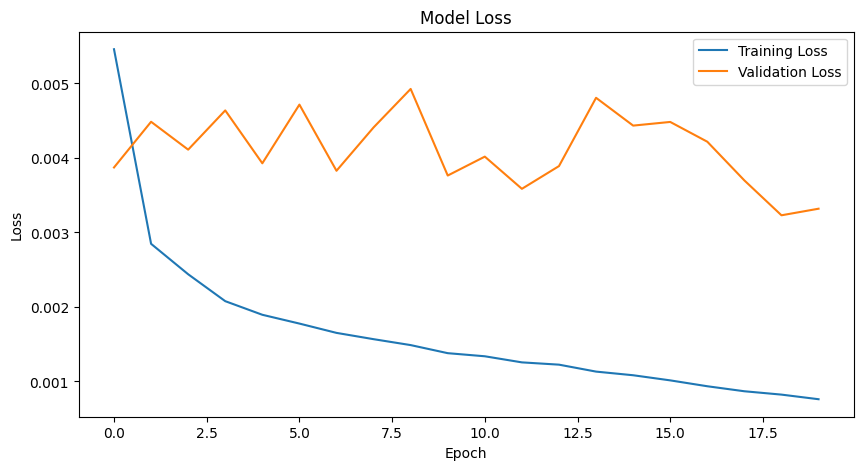

In [106]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
model.save("rainy_lstm_model.keras")

In [110]:
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [112]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Match lengths
min_len = min(
    len(y_test_actual),
    len(y_pred_actual)
)
y_test_actual = y_test_actual[:min_len]
y_pred_actual = y_pred_actual[:min_len]
# Metrics
mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)
mse = mean_squared_error(
    y_test_actual,
    y_pred_actual
)
rmse = np.sqrt(mse)
r2 = r2_score(
    y_test_actual,
    y_pred_actual
)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 16.593331330286343
RMSE: 30.303959745398085
R2 Score: 0.471536264652037


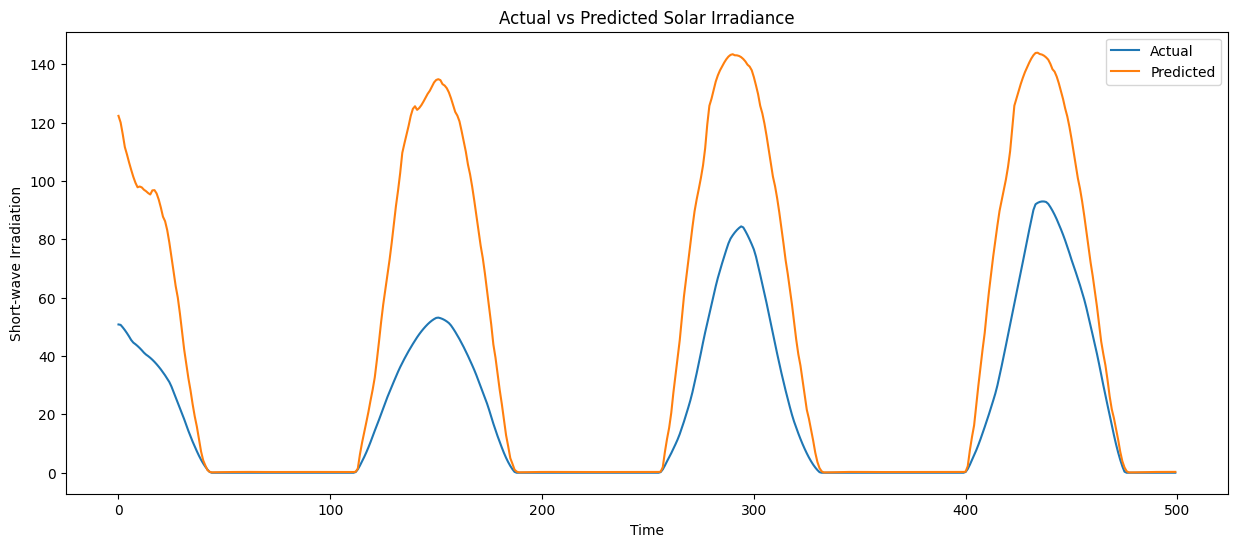

In [113]:
plt.figure(figsize=(15,6))
plt.plot(
    y_test_actual[:500],
    label="Actual"
)
plt.plot(
    y_pred_actual[:500],
    label="Predicted"
)
plt.title("Actual vs Predicted Solar Irradiance")
plt.xlabel("Time")
plt.ylabel("Short-wave Irradiation")
plt.legend()
plt.show()


In [117]:
plt.savefig("rainy_prediction_plot.png")

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_rainy_model.keras",
    monitor='val_loss',
    save_best_only=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)


<Figure size 640x480 with 0 Axes>

In [126]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
improved_model = Sequential()
# First LSTM Layer
improved_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
improved_model.add(Dropout(0.3))
# Second LSTM Layer
improved_model.add(
    LSTM(
        64,
        return_sequences=False
    )
)
improved_model.add(Dropout(0.3))
# Dense Layers
improved_model.add(Dense(32, activation='relu'))
improved_model.add(Dense(16, activation='relu'))
# Output Layer
improved_model.add(Dense(1))
improved_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
history_improved = improved_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],
    verbose=1
)


Epoch 1/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - loss: 0.0059 - mae: 0.0433 - val_loss: 0.0051 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 2/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - loss: 0.0029 - mae: 0.0310 - val_loss: 0.0055 - val_mae: 0.0407 - learning_rate: 0.0010
Epoch 3/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - loss: 0.0025 - mae: 0.0286 - val_loss: 0.0044 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 4/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 58s 48ms/step - loss: 0.0022 - mae: 0.0269 - val_loss: 0.0040 - val_mae: 0.0350 - learning_rate: 0.0010
Epoch 5/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - loss: 0.0020 - mae: 0.0253 - val_loss: 0.0044 - val_mae: 0.0345 - learning_rate: 0.0010
Epoch 6/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 60s 50ms/step - loss: 0.0018 - mae: 0.0240 - val_loss: 0.0036 - val_mae: 0.0328 - learning_rate: 0.0010
Epoch 7/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 56s 47ms/step - loss: 0.0017 - mae: 0.0230 - val_loss: 0.0043 - val_mae: 0.0341 - 

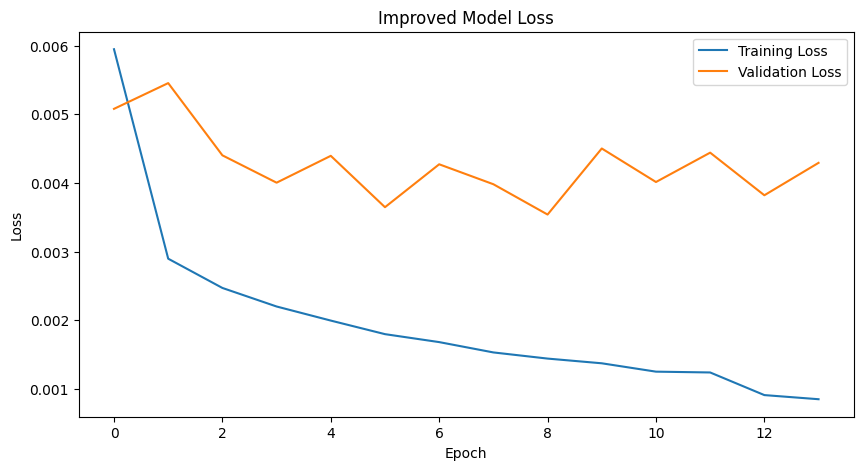

In [127]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)
plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [128]:
import matplotlib.pyplot as plt
predictions = improved_model.predict(X_test)
print(predictions[:5])


332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
[[0.27524152]
 [0.27654535]
 [0.2780286 ]
 [0.27937916]
 [0.27809605]]


In [129]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 0.034419404237952256
RMSE: 0.06987443287660211
R2 Score: 0.9317162887396016


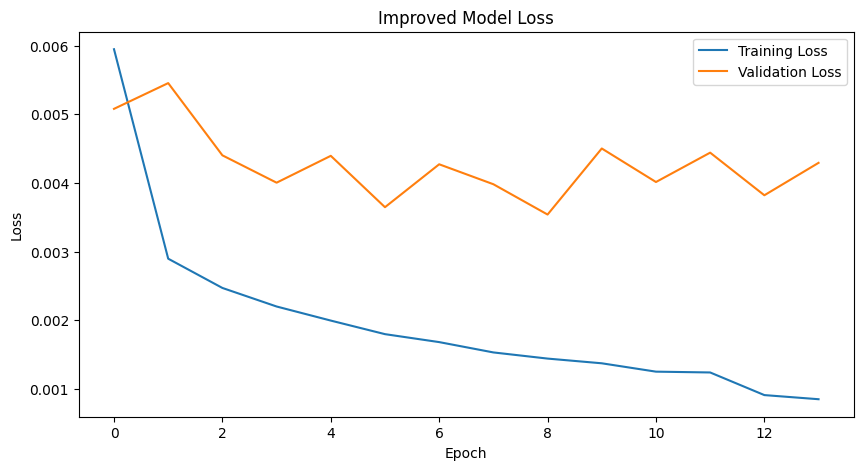

In [135]:
with open("metrics.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2 Score: {r2}\n")

improved_model.save("improved_lstm_model.keras")
import os
os.makedirs("results/rainy_graphs", exist_ok=True)
plt.figure(figsize=(10,5))
plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)
plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("results/graphs/rainy_loss_curve.png")
plt.show()


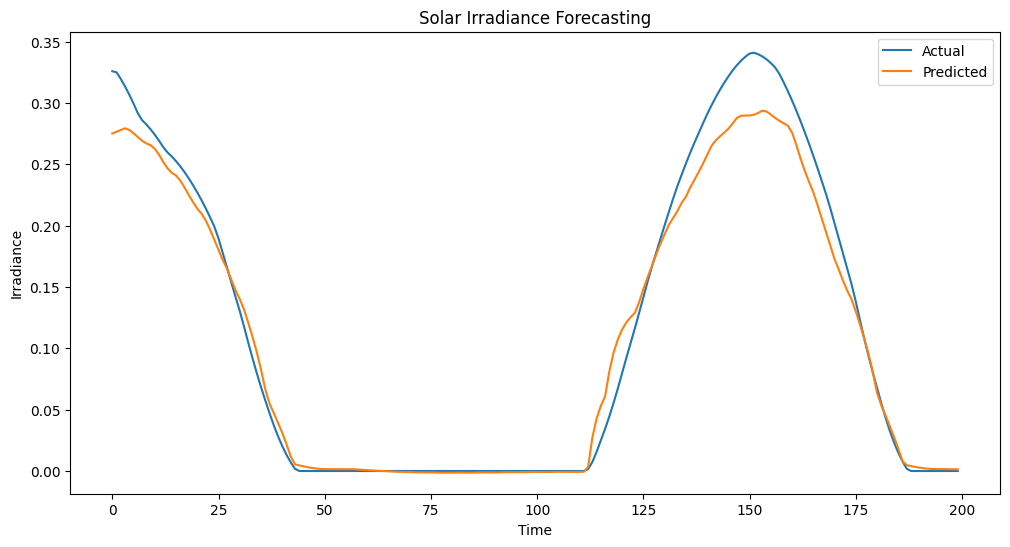

In [136]:
plt.figure(figsize=(12,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(predictions[:200], label='Predicted')
plt.title("Solar Irradiance Forecasting")
plt.xlabel("Time")
plt.ylabel("Irradiance")
plt.legend()
plt.savefig("results/graphs/rainy_Prediction.png")
plt.show()

In [137]:
with open("results/metrics.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2 Score: {r2}\n")

# **Winter Season Forecasting**

In [76]:
winter.columns = winter.columns.str.strip()

print(winter.columns)

Index(['Date Time', 'Time', 'Temperature', 'Relative Humidity', 'Pressure',
       'Wind speed', 'Wind direction', 'Rainfall', 'Snowfall', 'Snow depth',
       'Short-wave irradiation'],
      dtype='object')


In [77]:
winter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51983 entries, 0 to 51982
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date Time               51983 non-null  object 
 1   Time                    51983 non-null  object 
 2   Temperature             51983 non-null  float64
 3   Relative Humidity       51983 non-null  float64
 4   Pressure                51983 non-null  float64
 5   Wind speed              51983 non-null  float64
 6   Wind direction          51983 non-null  float64
 7   Rainfall                51983 non-null  float64
 8   Snowfall                51983 non-null  int64  
 9   Snow depth              51983 non-null  int64  
 10  Short-wave irradiation  51983 non-null  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 4.4+ MB


In [78]:
winter.isnull().sum()

,0
Date Time,0
Time,0
Temperature,0
Relative Humidity,0
Pressure,0
Wind speed,0
Wind direction,0
Rainfall,0
Snowfall,0
Snow depth,0


In [81]:
winter["Datetime"] = pd.to_datetime(

    winter["Date Time"].astype(str)
    + " "
    + winter["Time"].astype(str),

    format='mixed'
)

print(
    winter[["Date Time", "Time", "Datetime"]].head()
)

  Date Time  Time            Datetime
0  1/1/2004  0:10 2004-01-01 00:10:00
1  1/1/2004  0:20 2004-01-01 00:20:00
2  1/1/2004  0:30 2004-01-01 00:30:00
3  1/1/2004  0:40 2004-01-01 00:40:00
4  1/1/2004  0:50 2004-01-01 00:50:00


In [83]:
winter = winter.sort_values("Datetime")
winter.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Datetime
0,1/1/2004,0:10,285.19,92.73,1012.09,2.50,6.33,0.0,0,0,0.0,2004-01-01 00:10:00
1,1/1/2004,0:20,285.12,93.02,1012.17,2.51,7.51,0.0,0,0,0.0,2004-01-01 00:20:00
2,1/1/2004,0:30,285.05,93.31,1012.25,2.52,8.68,0.0,0,0,0.0,2004-01-01 00:30:00
3,1/1/2004,0:40,285.11,93.08,1012.36,2.53,9.25,0.0,0,0,0.0,2004-01-01 00:40:00
4,1/1/2004,0:50,285.32,92.33,1012.51,2.55,9.22,0.0,0,0,0.0,2004-01-01 00:50:00


In [139]:
winter.set_index("Datetime", inplace=True)
winter.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation
Datetime,,,,,,,,,,,
2004-01-01 00:10:00,1/1/2004,0:10,285.19,92.73,1012.09,2.50,6.33,0.0,0,0,0.0
2004-01-01 00:20:00,1/1/2004,0:20,285.12,93.02,1012.17,2.51,7.51,0.0,0,0,0.0
2004-01-01 00:30:00,1/1/2004,0:30,285.05,93.31,1012.25,2.52,8.68,0.0,0,0,0.0
2004-01-01 00:40:00,1/1/2004,0:40,285.11,93.08,1012.36,2.53,9.25,0.0,0,0,0.0
2004-01-01 00:50:00,1/1/2004,0:50,285.32,92.33,1012.51,2.55,9.22,0.0,0,0,0.0


In [140]:
winter["Hour"] = winter.index.hour
winter["Day"] = winter.index.day
winter["Month"] = winter.index.month
winter.head()

,Date Time,Time,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Short-wave irradiation,Hour,Day,Month
Datetime,,,,,,,,,,,,,,
2004-01-01 00:10:00,1/1/2004,0:10,285.19,92.73,1012.09,2.50,6.33,0.0,0,0,0.0,0,1,1
2004-01-01 00:20:00,1/1/2004,0:20,285.12,93.02,1012.17,2.51,7.51,0.0,0,0,0.0,0,1,1
2004-01-01 00:30:00,1/1/2004,0:30,285.05,93.31,1012.25,2.52,8.68,0.0,0,0,0.0,0,1,1
2004-01-01 00:40:00,1/1/2004,0:40,285.11,93.08,1012.36,2.53,9.25,0.0,0,0,0.0,0,1,1
2004-01-01 00:50:00,1/1/2004,0:50,285.32,92.33,1012.51,2.55,9.22,0.0,0,0,0.0,0,1,1


In [143]:
features = [
    "Temperature",
    "Relative Humidity",
    "Pressure",
    "Wind speed",
    "Wind direction",
    "Rainfall",
    "Snowfall",
    "Snow depth",
    "Hour",
    "Day",
    "Month"
]
target = "Short-wave irradiation"
X = winter[features]
y = winter[target]
print(X.head())
print(y.head())

                     Temperature  Relative Humidity  Pressure  Wind speed  \
Datetime                                                                    
2004-01-01 00:10:00       285.19              92.73   1012.09        2.50   
2004-01-01 00:20:00       285.12              93.02   1012.17        2.51   
2004-01-01 00:30:00       285.05              93.31   1012.25        2.52   
2004-01-01 00:40:00       285.11              93.08   1012.36        2.53   
2004-01-01 00:50:00       285.32              92.33   1012.51        2.55   

                     Wind direction  Rainfall  Snowfall  Snow depth  Hour  \
Datetime                                                                    
2004-01-01 00:10:00            6.33       0.0         0           0     0   
2004-01-01 00:20:00            7.51       0.0         0           0     0   
2004-01-01 00:30:00            8.68       0.0         0           0     0   
2004-01-01 00:40:00            9.25       0.0         0           0     0  

In [146]:
from sklearn.preprocessing import MinMaxScaler
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(X)
y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1))
print("X_scaled shape:", X_scaled.shape)
print("y_scaled shape:", y_scaled.shape)

X_scaled shape: (51983, 11)
y_scaled shape: (51983, 1)


In [147]:
X_scaled = pd.DataFrame(X_scaled, columns=features, index=winter.index)
y_scaled = pd.DataFrame(y_scaled, columns=[target], index=winter.index)
X_scaled.head()

,Temperature,Relative Humidity,Pressure,Wind speed,Wind direction,Rainfall,Snowfall,Snow depth,Hour,Day,Month
Datetime,,,,,,,,,,,
2004-01-01 00:10:00,0.056683,0.893610,0.692814,0.306173,0.017583,0.0,0.0,0.0,0.0,0.0,0.0
2004-01-01 00:20:00,0.054002,0.896967,0.697605,0.307407,0.020861,0.0,0.0,0.0,0.0,0.0,0.0
2004-01-01 00:30:00,0.051321,0.900324,0.702395,0.308642,0.024111,0.0,0.0,0.0,0.0,0.0,0.0
2004-01-01 00:40:00,0.053619,0.897661,0.708982,0.309877,0.025694,0.0,0.0,0.0,0.0,0.0,0.0
2004-01-01 00:50:00,0.061662,0.888979,0.717964,0.312346,0.025611,0.0,0.0,0.0,0.0,0.0,0.0


In [151]:
sequence_length = 24
def create_sequences(X, y, sequence_length):
    X_sequences = []
    y_sequences = []
    for i in range(sequence_length, len(X)):
        X_sequences.append(
            X.iloc[i-sequence_length:i].values
        )
        y_sequences.append(
            y.iloc[i].values
        )
    return np.array(X_sequences), np.array(y_sequences)
    X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    sequence_length
)
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)


X_seq shape: (53112, 24, 11)
y_seq shape: (53112, 1)


In [152]:
train_size = int(len(X_seq) * 0.8)
X_train = X_seq[:train_size]
X_test = X_seq[train_size:]
y_train = y_seq[:train_size]
y_test = y_seq[train_size:]
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (42489, 24, 11)
X_test shape: (10623, 24, 11)
y_train shape: (42489, 1)
y_test shape: (10623, 1)


In [158]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
model = Sequential()
# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
model.add(Dropout(0.2))
# Second LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)
model.add(Dropout(0.2))
# Dense Layers
model.add(Dense(32, activation='relu'))
# Output Layer
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - loss: 0.0050 - mae: 0.0424 - val_loss: 0.0052 - val_mae: 0.0391
Epoch 2/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - loss: 0.0029 - mae: 0.0314 - val_loss: 0.0045 - val_mae: 0.0357
Epoch 3/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 0.0024 - mae: 0.0286 - val_loss: 0.0042 - val_mae: 0.0348
Epoch 4/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0022 - mae: 0.0271 - val_loss: 0.0043 - val_mae: 0.0331
Epoch 5/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 0.0020 - mae: 0.0258 - val_loss: 0.0043 - val_mae: 0.0328
Epoch 6/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - loss: 0.0019 - mae: 0.0250 - val_loss: 0.0044 - val_mae: 0.0329
Epoch 7/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - loss: 0.0017 - mae: 0.0239 - val_loss: 0.0049 - val_mae: 0.0366
Epoch 8/20
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - loss: 0.0016 - mae: 0.0232 - val_loss: 0.0048 - val_mae: 0.0365
Epoch 9/20
1195/1195 ━━━

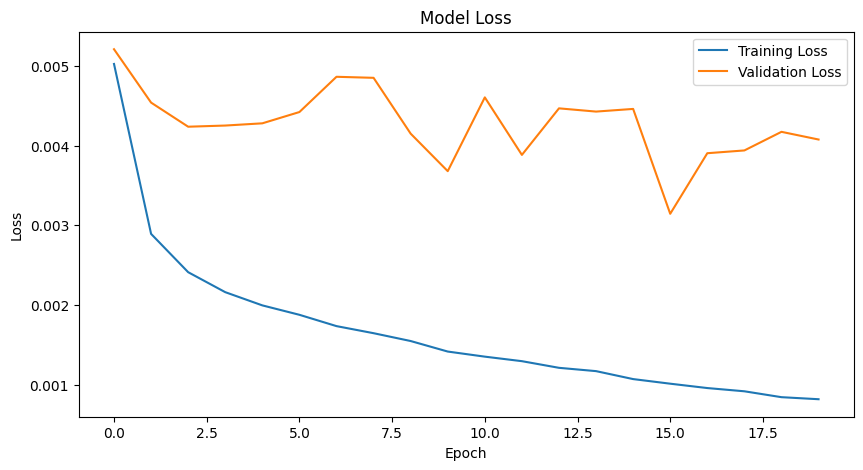

In [160]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [166]:
model.save("winter_lstm_model.keras")
y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [167]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
# Match lengths
min_len = min(
    len(y_test_actual),
    len(y_pred_actual)
)
y_test_actual = y_test_actual[:min_len]
y_pred_actual = y_pred_actual[:min_len]
# Metrics
mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)
mse = mean_squared_error(
    y_test_actual,
    y_pred_actual
)
rmse = np.sqrt(mse)
r2 = r2_score(
    y_test_actual,
    y_pred_actual
)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 16.891667276734665
RMSE: 30.848802731459823
R2 Score: 0.4715362628006582


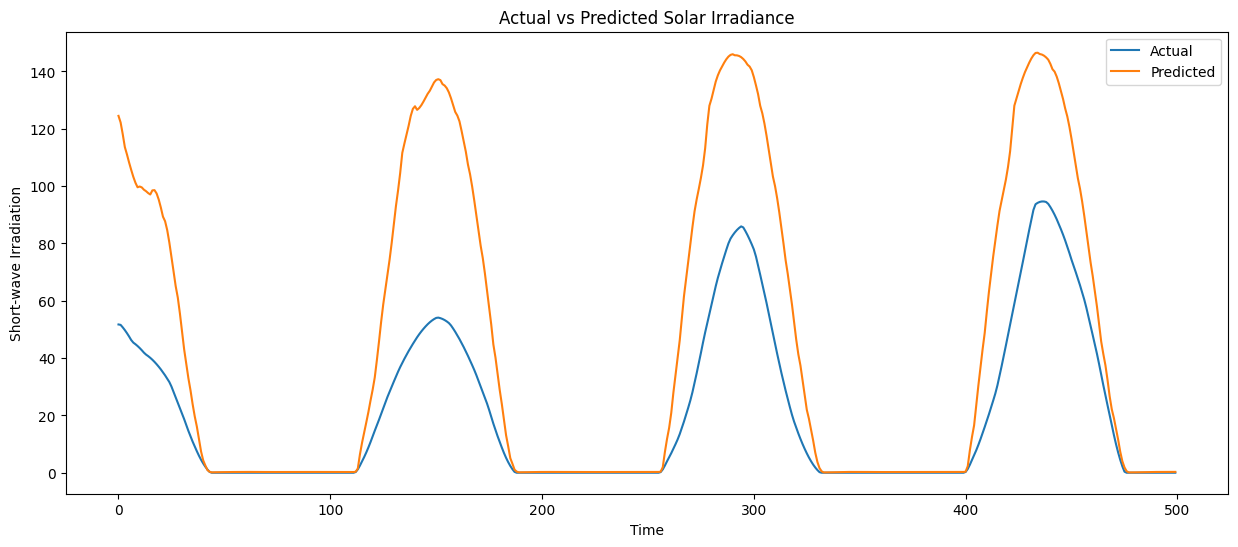

<Figure size 640x480 with 0 Axes>

In [169]:
plt.figure(figsize=(15,6))
plt.plot(
    y_test_actual[:500],
    label="Actual"
)
plt.plot(
    y_pred_actual[:500],
    label="Predicted"
)
plt.title("Actual vs Predicted Solar Irradiance")
plt.xlabel("Time")
plt.ylabel("Short-wave Irradiation")
plt.legend()
plt.show()
plt.savefig("winter_prediction_plot.png")

In [179]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_summer_model.keras",
    monitor='val_loss',
    save_best_only=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
 min_lr=0.00001
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
improved_model = Sequential()
# First LSTM Layer
improved_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
improved_model.add(Dropout(0.3))
# Second LSTM Layer
improved_model.add(
    LSTM(
        64,
        return_sequences=False
    )
)
improved_model.add(Dropout(0.3))
# Dense Layers
improved_model.add(Dense(32, activation='relu'))
improved_model.add(Dense(16, activation='relu'))
# Output Layer
improved_model.add(Dense(1))

improved_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)
history_improved = improved_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 61s 48ms/step - loss: 0.0055 - mae: 0.0431 - val_loss: 0.0051 - val_mae: 0.0420 - learning_rate: 0.0010
Epoch 2/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - loss: 0.0030 - mae: 0.0316 - val_loss: 0.0037 - val_mae: 0.0342 - learning_rate: 0.0010
Epoch 3/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 56s 47ms/step - loss: 0.0025 - mae: 0.0286 - val_loss: 0.0041 - val_mae: 0.0350 - learning_rate: 0.0010
Epoch 4/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - loss: 0.0023 - mae: 0.0272 - val_loss: 0.0042 - val_mae: 0.0373 - learning_rate: 0.0010
Epoch 5/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 58s 49ms/step - loss: 0.0021 - mae: 0.0257 - val_loss: 0.0037 - val_mae: 0.0332 - learning_rate: 0.0010
Epoch 6/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - loss: 0.0016 - mae: 0.0222 - val_loss: 0.0050 - val_mae: 0.0363 - learning_rate: 5.0000e-04
Epoch 7/50
1195/1195 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - loss: 0.0015 - mae: 0.0216 - val_loss: 0.0052 - val_mae: 0.038

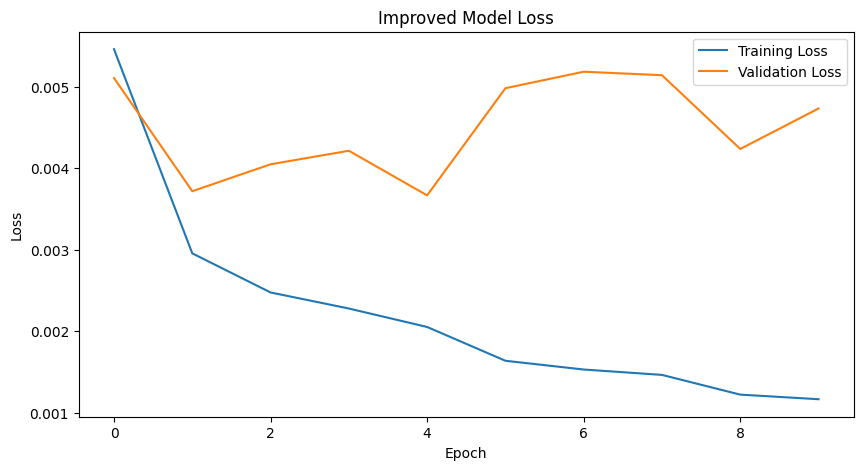

In [180]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)
plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [181]:
import matplotlib.pyplot as plt
predictions = improved_model.predict(X_test)
print(predictions[:5])

332/332 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step
[[0.2927067 ]
 [0.2952589 ]
 [0.29751125]
 [0.2994011 ]
 [0.3003304 ]]


In [182]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.035930610849607865
RMSE: 0.06705569964761193
R2 Score: 0.9371142968023112


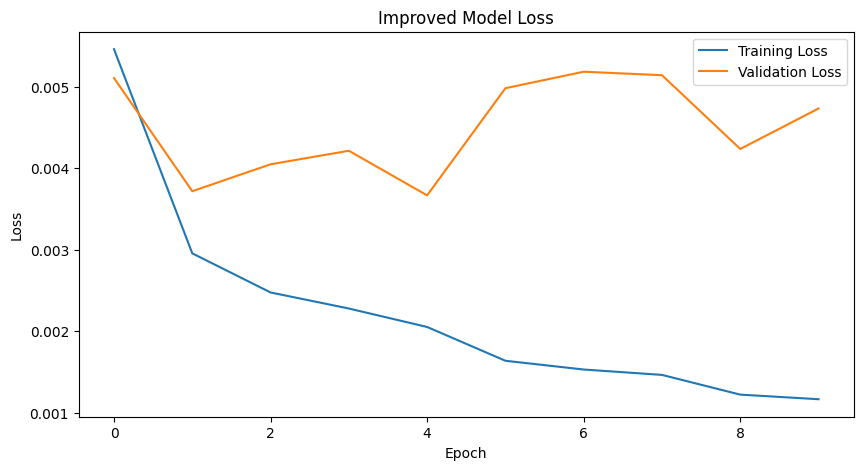

In [184]:
with open("metrics.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2 Score: {r2}\n")

improved_model.save("improved_lstm_model.keras")
import os
os.makedirs("results/graphs", exist_ok=True)

plt.figure(figsize=(10,5))

plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
)
plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
)
plt.title("Improved Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("results/graphs/winter_loss_curve.png")
plt.show()


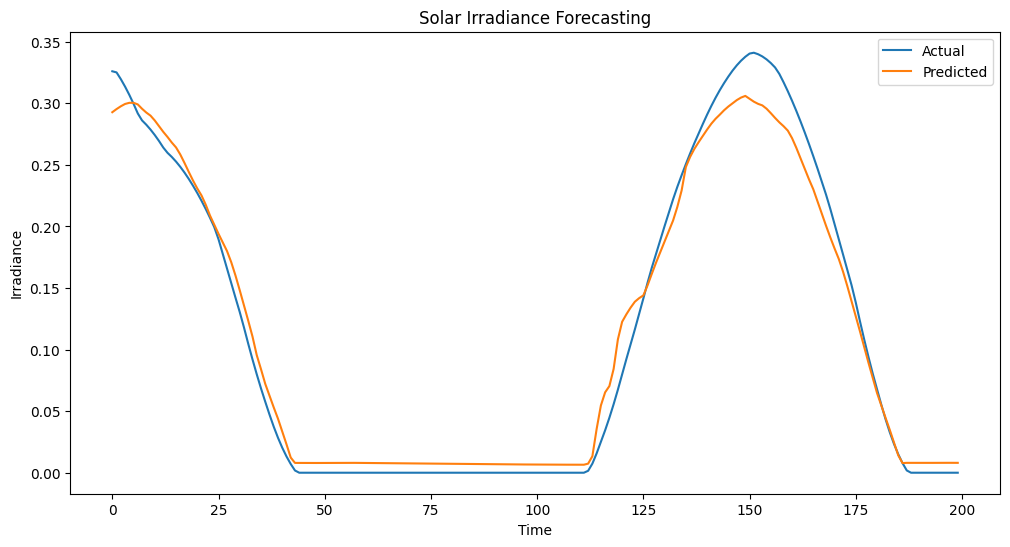

In [185]:
plt.figure(figsize=(12,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(predictions[:200], label='Predicted')
plt.title("Solar Irradiance Forecasting")
plt.xlabel("Time")
plt.ylabel("Irradiance")
plt.legend()
plt.savefig("results/graphs/Winter_Prediction.png")
plt.show()


In [186]:
with open("results/metrics.txt", "w") as f:
    f.write(f"MAE: {mae}\n")
    f.write(f"RMSE: {rmse}\n")
    f.write(f"R2 Score: {r2}\n")